# Final vLLM Baseline vs Quantized Benchmark on Vast.ai (1x NVIDIA L4)

This notebook is a **report-ready, reproducible benchmark pipeline** for comparing baseline vs quantized vLLM inference on a single NVIDIA L4 GPU.

## What this notebook includes
1. Environment setup and reproducibility capture
2. Shared config and robust cleanup/preflight utilities
3. **Controlled in-process microbenchmark** (explicitly not a server benchmark)
4. Quantization workflow (GPTQ W4A16 via llmcompressor)
5. **True local vLLM server benchmark** (`vllm serve` + `vllm bench serve`)
6. Practical L4 parameter sweep for server speed
7. Correct true perplexity / NLL benchmark on WikiText-2
8. Final summary tables, plots, and artifact completeness checks

## Methodology notes
- In-process microbenchmark is useful for controlled comparisons, but is not equivalent to real serving.
- Server benchmark section is the primary serving evaluation.
- Perplexity is computed with a correct sliding-window strategy that avoids overlap double-counting.
- Results are hardware/software specific to this environment (Vast.ai, 1x L4, installed versions).

## SECTION 2 — Environment and reproducibility

In [1]:
from __future__ import annotations

import gc
import json
import math
import os
import platform
import random
import re
import shlex
import signal
import subprocess
import sys
import time
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import requests
import torch
import transformers
import vllm
import llmcompressor
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset, load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from vllm import LLM, SamplingParams
from llmcompressor import oneshot
from llmcompressor.modifiers.quantization import GPTQModifier

sns.set_theme(style='whitegrid')
print('python:', sys.version.split()[0])
print('torch:', torch.__version__)
print('transformers:', transformers.__version__)
print('vllm:', vllm.__version__)
print('llmcompressor:', llmcompressor.__version__)
print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('cuda_available:', torch.cuda.is_available())

/workspace/venv-vllm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


python: 3.12.12
torch: 2.9.1+cu128
transformers: 4.57.3
vllm: 0.15.1
llmcompressor: 0.9.0.2
pandas: 2.3.3
numpy: 2.2.6
cuda_available: True


## SECTION 3 — Shared config

In [2]:
@dataclass(frozen=True)
class BenchmarkConfig:
    #model_id = 'Qwen/Qwen3-0.6B'
    #model_id: str = 'Qwen/Qwen3-1.7B'
    model_id = 'Qwen/Qwen3-4B'
    alt_model_id: str = 'Qwen/Qwen3-4B'

    #artifact_root = './artifacts/qwen3_0_6b_l4_final'
    #artifact_root: str = './artifacts/qwen3_1_7b_l4_final'
    artifact_root = './artifacts/qwen3_4b_l4_final'
    seed: int = 42

    gpu_mem_util: float = 0.90
    max_model_len: int = 2048
    dtype: str = 'half'

    warmup_iters: int = 2
    timed_runs: int = 8
    batch_sizes: tuple[int, ...] = (1, 4, 8, 16, 32)
    max_new_tokens_options: tuple[int, ...] = (32, 128, 256, 512)

    max_sequence_length: int = 1024
    num_calibration_samples: int = 256
    eval_samples: int = 256

    server_host: str = '127.0.0.1'
    server_port: int = 18000
    server_timeout_s: int = 240
    server_log_tail_lines: int = 200

    # L4 tuning candidates
    tune_gpu_mem_utils: tuple[float, ...] = (0.85, 0.90)
    tune_max_num_seqs: tuple[int, ...] = (16, 32, 64)
    tune_max_num_batched_tokens: tuple[int, ...] = (2048, 4096, 8192)

    # VRAM guardrails
    min_free_gb_for_baseline: float = 11.0
    min_free_gb_for_quant_export: float = 10.0
    min_free_gb_for_server: float = 10.0
    min_free_gb_for_ppl: float = 8.0

CFG = BenchmarkConfig()
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S_utc')
ROOT = Path(CFG.artifact_root) / RUN_ID
DIRS = {
    'root': ROOT,
    'logs': ROOT / 'logs',
    'raw': ROOT / 'raw',
    'summary': ROOT / 'summary',
    'figures': ROOT / 'figures',
    'models': ROOT / 'models',
    'bench': ROOT / 'bench',
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

(ROOT / 'config.json').write_text(json.dumps(asdict(CFG), indent=2))
print('Artifacts root:', ROOT)

Artifacts root: artifacts/qwen3_4b_l4_final/20260324_190308_utc


In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def run_cmd(cmd: list[str], check: bool = False, timeout: int | None = None, env: dict[str, str] | None = None) -> subprocess.CompletedProcess:
    cp = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout, env=env)
    if check and cp.returncode != 0:
        raise RuntimeError(
            f"Command failed ({cp.returncode}): {' '.join(cmd)}\nSTDOUT:\n{cp.stdout}\nSTDERR:\n{cp.stderr}"
        )
    return cp


def nvidia_smi_summary() -> dict[str, Any]:
    query = run_cmd([
        'nvidia-smi',
        '--query-gpu=name,memory.total,memory.free,memory.used,driver_version',
        '--format=csv,noheader,nounits',
    ])
    full = run_cmd(['nvidia-smi'])
    return {
        'query_returncode': query.returncode,
        'query_output': query.stdout.strip(),
        'query_stderr': query.stderr.strip(),
        'full_returncode': full.returncode,
        'full_output': full.stdout,
        'full_stderr': full.stderr,
    }


def gpu_mem_snapshot_gb() -> dict[str, float]:
    if not torch.cuda.is_available():
        return {'free_gb': 0.0, 'total_gb': 0.0, 'used_gb': 0.0}
    free_b, total_b = torch.cuda.mem_get_info()
    free_gb = free_b / (1024**3)
    total_gb = total_b / (1024**3)
    return {'free_gb': free_gb, 'total_gb': total_gb, 'used_gb': total_gb - free_gb}


def list_gpu_compute_processes() -> pd.DataFrame:
    cp = run_cmd([
        'nvidia-smi',
        '--query-compute-apps=pid,process_name,used_memory',
        '--format=csv,noheader,nounits',
    ])
    if cp.returncode != 0 or not cp.stdout.strip():
        return pd.DataFrame(columns=['pid', 'process_name', 'used_memory_mb'])
    rows = []
    for line in cp.stdout.strip().splitlines():
        parts = [x.strip() for x in line.split(',')]
        if len(parts) >= 3:
            try:
                rows.append({'pid': int(parts[0]), 'process_name': parts[1], 'used_memory_mb': float(parts[2])})
            except Exception:
                pass
    return pd.DataFrame(rows)


def list_system_processes() -> pd.DataFrame:
    cp = run_cmd(['ps', '-eo', 'pid,ppid,comm,args'])
    if cp.returncode != 0:
        return pd.DataFrame(columns=['pid', 'ppid', 'comm', 'args'])
    rows = []
    for ln in cp.stdout.splitlines()[1:]:
        cols = ln.strip().split(None, 3)
        if len(cols) == 4:
            try:
                rows.append({'pid': int(cols[0]), 'ppid': int(cols[1]), 'comm': cols[2], 'args': cols[3]})
            except Exception:
                pass
    return pd.DataFrame(rows)


def find_vllm_related_pids() -> list[int]:
    ps = list_system_processes()
    if ps.empty:
        return []
    pat = r'vllm serve|vllm\.entrypoints|VLLM::EngineCore|api_server|python.*vllm|openai\.api'
    mask = ps['args'].str.contains(pat, case=False, regex=True, na=False)
    return sorted(ps.loc[mask, 'pid'].unique().tolist())


def kill_pid(pid: int, timeout_s: float = 5.0) -> None:
    try:
        os.kill(pid, signal.SIGTERM)
    except Exception:
        return
    t0 = time.time()
    while time.time() - t0 < timeout_s:
        try:
            os.kill(pid, 0)
            time.sleep(0.1)
        except ProcessLookupError:
            return
        except Exception:
            return
    try:
        os.kill(pid, signal.SIGKILL)
    except Exception:
        pass


def cleanup_stale_vllm(known_llms: list[Any] | None = None) -> None:
    if known_llms:
        for llm in known_llms:
            try:
                if hasattr(llm, 'llm_engine') and hasattr(llm.llm_engine, 'engine_core'):
                    llm.llm_engine.engine_core.shutdown()
            except Exception:
                pass
    for pid in find_vllm_related_pids():
        kill_pid(pid)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


def assert_min_free_gb(min_free_gb: float, stage: str) -> None:
    mem = gpu_mem_snapshot_gb()
    if mem['free_gb'] < min_free_gb:
        raise RuntimeError(
            f"Insufficient VRAM at stage={stage}: free={mem['free_gb']:.2f} GB < required={min_free_gb:.2f} GB. "
            "Lower max_model_len, max_new_tokens, batch/concurrency, or use a smaller model."
        )

set_seed(CFG.seed)

env_info = {
    'python': sys.version,
    'torch': torch.__version__,
    'transformers': transformers.__version__,
    'vllm': vllm.__version__,
    'llmcompressor': llmcompressor.__version__,
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'cuda_available': torch.cuda.is_available(),
    'cuda_version_torch': torch.version.cuda,
    'gpu_name_torch': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    'nvidia_smi': nvidia_smi_summary(),
    'gpu_mem_snapshot_gb': gpu_mem_snapshot_gb(),
}
(DIRS['summary'] / 'environment.json').write_text(json.dumps(env_info, indent=2))
print('Saved environment.json')
display(list_gpu_compute_processes())

Saved environment.json


,pid,process_name,used_memory_mb
0,171931,/workspace/venv-vllm/bin/python,426.0


## SECTION 4 — Prompt and data setup

In [4]:
PROMPT_BANK = [
    'Write a detailed but concise explanation of how KV cache affects transformer inference latency and throughput.',
    'You are preparing a production rollout for a quantized LLM endpoint. List key validation checks and why each matters.',
    'Compare GPTQ W4A16 and FP16 inference for an online chatbot workload with moderate sequence lengths.',
    'Explain paged attention and its practical impact on memory fragmentation in high-throughput serving.',
    'Give a structured analysis of why measured speedup can differ between microbenchmarks and API benchmarks.',
    'Design a benchmark plan that separates model compute, scheduling, and network overhead in LLM serving.',
    'What are common mistakes when reporting latency metrics for batch-serving LLM systems?',
    'Provide recommendations for robust benchmark reproducibility on rented GPU instances such as Vast.ai.',
    'Explain how max_num_seqs and max_num_batched_tokens influence utilization and stability.',
    'Summarize constraints and risks when evaluating quantized models for user-facing generation quality.',
    'Describe tradeoffs among throughput, p95 latency, and quality regression for quantized deployment decisions.',
    'Write a compact report section on hardware-specific benchmarking limitations using a single NVIDIA L4.',
]


def build_prompt_batch(batch_size: int) -> list[str]:
    reps = math.ceil(batch_size / len(PROMPT_BANK))
    return (PROMPT_BANK * reps)[:batch_size]


def build_synthetic_server_scenarios() -> list[dict[str, int]]:
    return [
        {'input_len': 128, 'output_len': 32},
        {'input_len': 256, 'output_len': 64},
        {'input_len': 512, 'output_len': 128},
    ]


WIKITEXT = load_dataset('wikitext', 'wikitext-2-raw-v1', split='test')
print('wikitext test rows:', len(WIKITEXT))

wikitext test rows: 4358


## SECTION 5 — Controlled in-process microbenchmark

This section is intentionally a **controlled in-process microbenchmark**.
- It uses `LLM.generate(...)` directly in Python.
- Latency here is a **proxy**, not true API request latency.
- Use Section 7 as the primary serving benchmark.

In [5]:
def build_llm(model_ref: str, *, quantization: str | None = None, gpu_mem_util: float | None = None) -> LLM:
    kwargs = dict(
        model=model_ref,
        dtype=CFG.dtype,
        gpu_memory_utilization=(gpu_mem_util if gpu_mem_util is not None else CFG.gpu_mem_util),
        max_model_len=CFG.max_model_len,
        trust_remote_code=True,
        disable_log_stats=True,
    )
    if quantization is not None:
        kwargs['quantization'] = quantization
    return LLM(**kwargs)


def run_microbenchmark(condition: str, model_ref: str, *, quantization: str | None = None) -> tuple[pd.DataFrame, pd.DataFrame]:
    assert_min_free_gb(CFG.min_free_gb_for_baseline, f'microbenchmark:{condition}')
    cleanup_stale_vllm()
    llm = build_llm(model_ref, quantization=quantization)

    rows = []
    try:
        for bs in CFG.batch_sizes:
            prompts = build_prompt_batch(bs)
            for max_new in CFG.max_new_tokens_options:
                sp = SamplingParams(temperature=0.0, max_tokens=max_new)
                for _ in range(CFG.warmup_iters):
                    _ = llm.generate(prompts, sp)

                for run_idx in range(CFG.timed_runs):
                    t0 = time.time()
                    outs = llm.generate(prompts, sp)
                    t1 = time.time()

                    elapsed = t1 - t0
                    total_tokens = sum(len(o.outputs[0].token_ids) for o in outs)
                    rows.append({
                        'condition': condition,
                        'batch_size': bs,
                        'max_new_tokens': max_new,
                        'run_idx': run_idx,
                        'elapsed_s': elapsed,
                        'total_new_tokens': total_tokens,
                        'tokens_per_sec': total_tokens / elapsed if elapsed > 0 else np.nan,
                        'batch_throughput_batches_per_s': 1.0 / elapsed if elapsed > 0 else np.nan,
                        'latency_proxy_s_per_request': elapsed / bs,
                        'latency_note': 'Proxy only (in-process batch elapsed / batch size)',
                    })
    finally:
        cleanup_stale_vllm([llm])

    raw = pd.DataFrame(rows)
    summary = raw.groupby(['condition', 'batch_size', 'max_new_tokens'], as_index=False).agg(
        tokens_per_sec_mean=('tokens_per_sec', 'mean'),
        tokens_per_sec_std=('tokens_per_sec', 'std'),
        batch_throughput_mean=('batch_throughput_batches_per_s', 'mean'),
        latency_proxy_mean=('latency_proxy_s_per_request', 'mean'),
        runs=('run_idx', 'count'),
    )
    return raw, summary

In [6]:
# Baseline microbenchmark
micro_base_raw, micro_base_summary = run_microbenchmark(
    'micro_baseline_fp16',
    CFG.model_id,
    quantization=None,
)
micro_base_raw.to_csv(DIRS['raw'] / 'micro_baseline_raw.csv', index=False)
micro_base_summary.to_csv(DIRS['summary'] / 'micro_baseline_summary.csv', index=False)
display(micro_base_summary.head())

INFO 03-24 19:03:13 [utils.py:261] non-default args: {'trust_remote_code': True, 'dtype': 'half', 'max_model_len': 2048, 'disable_log_stats': True, 'model': 'Qwen/Qwen3-4B'}


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


INFO 03-24 19:03:20 [model.py:541] Resolved architecture: Qwen3ForCausalLM
WARNING 03-24 19:03:20 [model.py:1885] Casting torch.bfloat16 to torch.float16.
INFO 03-24 19:03:20 [model.py:1561] Using max model len 2048


2026-03-24 19:03:20,949	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


INFO 03-24 19:03:20 [scheduler.py:226] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 03-24 19:03:20 [vllm.py:624] Asynchronous scheduling is enabled.
WARNING 03-24 19:03:25 [system_utils.py:140] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
(EngineCore_DP0 pid=172419) INFO 03-24 19:03:29 [core.py:96] Initializing a V1 LLM engine (v0.15.1) with config: model='Qwen/Qwen3-4B', speculative_config=None, tokenizer='Qwen/Qwen3-4B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.float16, max_seq_len=2048, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, enable_return_routed_e

...

(EngineCore_DP0 pid=172419) INFO 03-24 19:04:03 [backends.py:302] Cache the graph of compile range (1, 8192) for later use
(EngineCore_DP0 pid=172419) INFO 03-24 19:04:06 [backends.py:319] Compiling a graph for compile range (1, 8192) takes 2.51 s
(EngineCore_DP0 pid=172419) INFO 03-24 19:04:06 [monitor.py:34] torch.compile takes 9.10 s in total
(EngineCore_DP0 pid=172419) INFO 03-24 19:04:07 [gpu_worker.py:356] Available KV cache memory: 30.93 GiB
(EngineCore_DP0 pid=172419) INFO 03-24 19:04:07 [kv_cache_utils.py:1307] GPU KV cache size: 225,248 tokens
(EngineCore_DP0 pid=172419) INFO 03-24 19:04:07 [kv_cache_utils.py:1312] Maximum concurrency for 2,048 tokens per request: 109.98x


Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:02<00:00, 24.12it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:01<00:00, 28.14it/s]


(EngineCore_DP0 pid=172419) INFO 03-24 19:04:11 [gpu_model_runner.py:5063] Graph capturing finished in 4 secs, took 0.53 GiB
(EngineCore_DP0 pid=172419) INFO 03-24 19:04:11 [core.py:272] init engine (profile, create kv cache, warmup model) took 21.23 seconds
(EngineCore_DP0 pid=172419) INFO 03-24 19:04:12 [vllm.py:624] Asynchronous scheduling is enabled.
INFO 03-24 19:04:13 [llm.py:343] Supported tasks: ['generate']


Processed prompts: 100%|██████████| 32/32 [00:07<00:00,  4.04it/s, est. speed input: 76.61 toks/s, output: 2071.12 toks/s]
[rank0]:[W324 19:14:23.741653953 ProcessGroupNCCL.cpp:1524] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())


,condition,batch_size,max_new_tokens,tokens_per_sec_mean,tokens_per_sec_std,batch_throughput_mean,latency_proxy_mean,runs
0,micro_baseline_fp16,1,32,81.758208,0.102334,2.554944,0.391399,8
1,micro_baseline_fp16,1,128,82.582003,0.208435,0.645172,1.549983,8
2,micro_baseline_fp16,1,256,82.800691,0.020642,0.323440,3.091762,8
3,micro_baseline_fp16,1,512,82.854439,0.014530,0.161825,6.179512,8
4,micro_baseline_fp16,4,32,307.219783,0.382247,2.400155,0.104160,8


## SECTION 6 — Quantization workflow (GPTQ W4A16)

In [7]:
def build_calibration_dataset(tokenizer: AutoTokenizer, n: int) -> Dataset:
    ds = load_dataset('wikitext', 'wikitext-2-raw-v1', split='train')
    texts = [x['text'] for x in ds if x['text'].strip()][:n]
    calib = Dataset.from_dict({'text': texts})

    def tok(ex):
        return tokenizer(
            ex['text'],
            truncation=True,
            max_length=CFG.max_sequence_length,
            add_special_tokens=False,
            padding=False,
        )

    return calib.map(tok, remove_columns=['text'])


def quantize_gptq_w4a16(model_id: str, out_dir: Path, force: bool = False) -> Path:
    if out_dir.exists() and any(out_dir.iterdir()) and not force:
        print('Using existing quantized artifact:', out_dir)
        return out_dir

    assert_min_free_gb(CFG.min_free_gb_for_quant_export, 'quantization_export')
    cleanup_stale_vllm()

    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(model_id, dtype='auto', trust_remote_code=True)
    model = model.to('cuda')
    model.eval()

    calib_ds = build_calibration_dataset(tokenizer, CFG.num_calibration_samples)

    recipe = GPTQModifier(
        targets='Linear',
        scheme='W4A16',
        ignore=['lm_head'],
    )

    out_dir.mkdir(parents=True, exist_ok=True)
    oneshot(
        model=model,
        dataset=calib_ds,
        recipe=recipe,
        max_seq_length=CFG.max_sequence_length,
        num_calibration_samples=CFG.num_calibration_samples,
        output_dir=str(out_dir),
    )

    tokenizer.save_pretrained(str(out_dir))
    (out_dir / 'quantization_metadata.json').write_text(json.dumps({
        'source_model': model_id,
        'scheme': 'W4A16',
        'num_calibration_samples': CFG.num_calibration_samples,
        'max_sequence_length': CFG.max_sequence_length,
    }, indent=2))

    del model
    cleanup_stale_vllm()
    return out_dir


QUANT_MODEL_DIR = DIRS['models'] / f"{CFG.model_id.split('/')[-1]}_gptq_w4a16"
quant_path = quantize_gptq_w4a16(CFG.model_id, QUANT_MODEL_DIR, force=False)
print('Quantized path:', quant_path)

Map: 100%|██████████| 256/256 [00:00<00:00, 3802.16 examples/s]


2026-03-24T19:14:32.990975+0000 | reset | INFO - Compression lifecycle reset
2026-03-24T19:14:32.992773+0000 | from_modifiers | INFO - Creating recipe from modifiers
2026-03-24T19:14:33.048195+0000 | initialize | INFO - Compression lifecycle initialized for 1 modifiers
2026-03-24T19:14:33.048716+0000 | IndependentPipeline | INFO - Inferred `SequentialPipeline` for `GPTQModifier`


(1/37): Calibrating: 100%|██████████| 256/256 [00:02<00:00, 124.85it/s]

2026-03-24T19:14:40.024447+0000 | compress_modules | INFO - Quantizing model.layers.0.self_attn.q_proj using 256 samples


2026-03-24T19:14:41.134767+0000 | compress | METRIC - time 1.11s
2026-03-24T19:14:41.135420+0000 | compress | METRIC - error 0.77
2026-03-24T19:14:41.136363+0000 | compress | METRIC - GPU 0 | usage: 6.78% | total memory: 48 GB
2026-03-24T19:14:41.136709+0000 | compress | METRIC - Compressed module size: 21.21728 MB
2026-03-24T19:14:41.137293+0000 | compress_modules | INFO - Quantizing model.layers.0.self_attn.k_proj using 256 samples
2026-03-24T19:14:42.008326+0000 | compress | METRIC - time 0.87s
2026-03-24T19:14:42.008800+0000 | compress | METRIC - error 0.21
2026-03-24T19:14:42.009341+0000 | compress | METRIC - GPU 0 | usage: 6.78% | total memory: 48 GB
2026-03-24T19:14:42.009741+0000 | compress | METRIC - Compressed module size: 5.30432 MB
2026-03-24T19:14:42.010170+0000 | compress_modules | INFO - Quantizing model.layers.0.self_attn.v_proj using 256 samples
2026-03-24T19:14:42.867784+0000 | compress | METRIC - time 0.86s
2026-03-24T19:14:42.868464+0000 | compress | METRIC - error 

...

(37/37): Propagating: 100%|██████████| 256/256 [00:00<00:00, 4265.21it/s]

2026-03-24T19:21:45.429571+0000 | finalize | INFO - Compression lifecycle finalized for 1 modifiers


2026-03-24T19:21:45.471450+0000 | get_model_compressor | INFO - skip_sparsity_compression_stats set to True. Skipping sparsity compression statistic calculations. No sparsity compressor will be applied.


Compressing model: 252it [00:30,  8.23it/s]


Quantized path: artifacts/qwen3_4b_l4_final/20260324_190308_utc/models/Qwen3-4B_gptq_w4a16


In [8]:
# Quantized microbenchmark
micro_quant_raw, micro_quant_summary = run_microbenchmark(
    'micro_quant_gptq_w4a16',
    str(quant_path),
    quantization='compressed-tensors',
)
micro_quant_raw.to_csv(DIRS['raw'] / 'micro_quant_raw.csv', index=False)
micro_quant_summary.to_csv(DIRS['summary'] / 'micro_quant_summary.csv', index=False)
display(micro_quant_summary.head())

INFO 03-24 19:22:20 [utils.py:261] non-default args: {'trust_remote_code': True, 'dtype': 'half', 'max_model_len': 2048, 'disable_log_stats': True, 'quantization': 'compressed-tensors', 'model': 'artifacts/qwen3_4b_l4_final/20260324_190308_utc/models/Qwen3-4B_gptq_w4a16'}


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


INFO 03-24 19:22:20 [model.py:541] Resolved architecture: Qwen3ForCausalLM
WARNING 03-24 19:22:20 [model.py:1885] Casting torch.bfloat16 to torch.float16.
INFO 03-24 19:22:20 [model.py:1561] Using max model len 2048
INFO 03-24 19:22:20 [scheduler.py:226] Chunked prefill is enabled with max_num_batched_tokens=8192.


The tokenizer you are loading from 'artifacts/qwen3_4b_l4_final/20260324_190308_utc/models/Qwen3-4B_gptq_w4a16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


(EngineCore_DP0 pid=173719) INFO 03-24 19:22:26 [core.py:96] Initializing a V1 LLM engine (v0.15.1) with config: model='artifacts/qwen3_4b_l4_final/20260324_190308_utc/models/Qwen3-4B_gptq_w4a16', speculative_config=None, tokenizer='artifacts/qwen3_4b_l4_final/20260324_190308_utc/models/Qwen3-4B_gptq_w4a16', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.float16, max_seq_len=2048, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=compressed-tensors, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_fallback=False, disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_parser_plugin='', enable_in_reasoning=False), observability_config=Observabili

...

(EngineCore_DP0 pid=173719) INFO 03-24 19:22:51 [gpu_model_runner.py:5063] Graph capturing finished in 5 secs, took 0.58 GiB
(EngineCore_DP0 pid=173719) INFO 03-24 19:22:51 [core.py:272] init engine (profile, create kv cache, warmup model) took 21.63 seconds


(EngineCore_DP0 pid=173719) The tokenizer you are loading from 'artifacts/qwen3_4b_l4_final/20260324_190308_utc/models/Qwen3-4B_gptq_w4a16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


(EngineCore_DP0 pid=173719) INFO 03-24 19:22:52 [vllm.py:624] Asynchronous scheduling is enabled.
INFO 03-24 19:22:52 [llm.py:343] Supported tasks: ['generate']


Processed prompts: 100%|██████████| 32/32 [00:03<00:00,  8.37it/s, est. speed input: 158.49 toks/s, output: 4284.98 toks/s]
[rank0]:[W324 19:27:18.573595621 ProcessGroupNCCL.cpp:1524] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())


,condition,batch_size,max_new_tokens,tokens_per_sec_mean,tokens_per_sec_std,batch_throughput_mean,latency_proxy_mean,runs
0,micro_quant_gptq_w4a16,1,32,193.464259,0.866238,6.045758,0.165408,8
1,micro_quant_gptq_w4a16,1,128,199.819197,0.107028,1.561087,0.640579,8
2,micro_quant_gptq_w4a16,1,256,200.484077,0.156079,0.783141,1.276910,8
3,micro_quant_gptq_w4a16,1,512,200.498383,0.050975,0.391598,2.553637,8
4,micro_quant_gptq_w4a16,4,32,732.147306,2.038957,5.719901,0.043707,8


In [9]:
micro_merge = micro_base_summary.merge(
    micro_quant_summary,
    on=['batch_size', 'max_new_tokens'],
    suffixes=('_base', '_quant'),
)
micro_merge['speedup_x'] = micro_merge['tokens_per_sec_mean_quant'] / micro_merge['tokens_per_sec_mean_base']
micro_merge.to_csv(DIRS['summary'] / 'micro_comparison.csv', index=False)

display(micro_merge[['batch_size', 'max_new_tokens', 'tokens_per_sec_mean_base', 'tokens_per_sec_mean_quant', 'speedup_x']].head())

,batch_size,max_new_tokens,tokens_per_sec_mean_base,tokens_per_sec_mean_quant,speedup_x
0,1,32,81.758208,193.464259,2.366298
1,1,128,82.582003,199.819197,2.419646
2,1,256,82.800691,200.484077,2.421285
3,1,512,82.854439,200.498383,2.419887
4,4,32,307.219783,732.147306,2.383139


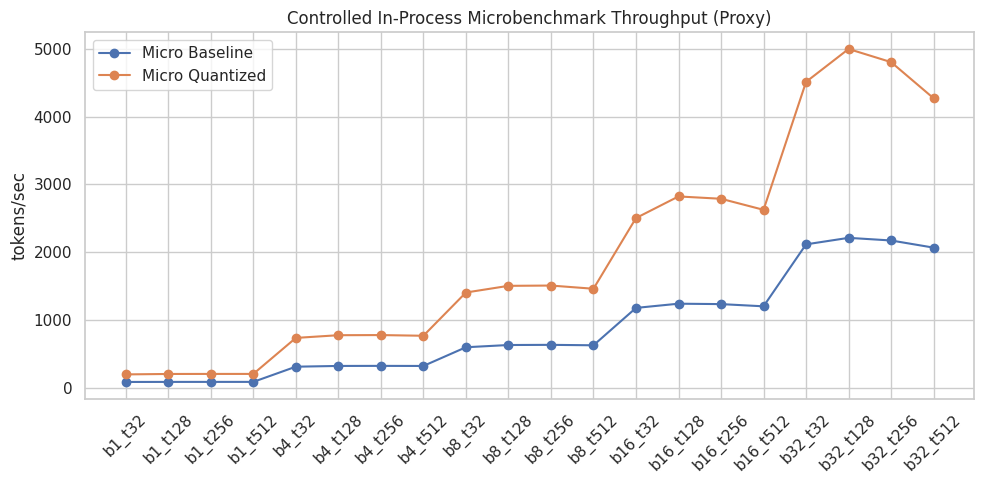

In [10]:
plt.figure(figsize=(10,5))
plot_df = micro_merge.copy()
plot_df['scenario'] = plot_df.apply(lambda r: f"b{int(r.batch_size)}_t{int(r.max_new_tokens)}", axis=1)
plt.plot(plot_df['scenario'], plot_df['tokens_per_sec_mean_base'], marker='o', label='Micro Baseline')
plt.plot(plot_df['scenario'], plot_df['tokens_per_sec_mean_quant'], marker='o', label='Micro Quantized')
plt.xticks(rotation=45)
plt.ylabel('tokens/sec')
plt.title('Controlled In-Process Microbenchmark Throughput (Proxy)')
plt.legend()
plt.tight_layout()
plt.savefig(DIRS['figures'] / 'micro_throughput_comparison.png', dpi=160)
plt.show()

## SECTION 7 — TRUE vLLM server benchmark (localhost)

This section launches local `vllm serve` processes and benchmarks through the API path.
It is the primary serving benchmark.

In [11]:
def port_in_use(host: str, port: int) -> bool:
    import socket
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0


def wait_for_server_ready(base_url: str, timeout_s: int, poll_s: float = 1.0) -> None:
    t0 = time.time()
    last_err = None
    while time.time() - t0 < timeout_s:
        try:
            r = requests.get(f"{base_url}/v1/models", timeout=2)
            if r.status_code == 200:
                return
            last_err = f"status={r.status_code}, body={r.text[:200]}"
        except Exception as e:
            last_err = str(e)
        time.sleep(poll_s)
    raise RuntimeError(f'Server failed to become ready within {timeout_s}s. Last error: {last_err}')


def start_vllm_server(
    model_ref: str,
    *,
    quantization: str | None,
    gpu_mem_util: float,
    max_num_seqs: int,
    max_num_batched_tokens: int,
    host: str,
    port: int,
    log_prefix: str,
) -> tuple[subprocess.Popen, Path, Path]:
    if port_in_use(host, port):
        raise RuntimeError(f'Port already in use: {host}:{port}. Stop stale server first.')

    cmd = [
        'vllm', 'serve', model_ref,
        '--host', host,
        '--port', str(port),
        '--dtype', CFG.dtype,
        '--gpu-memory-utilization', str(gpu_mem_util),
        '--max-model-len', str(CFG.max_model_len),
        '--max-num-seqs', str(max_num_seqs),
        '--max-num-batched-tokens', str(max_num_batched_tokens),
        '--served-model-name', CFG.model_id,
        '--trust-remote-code',
    ]
    if quantization is not None:
        cmd += ['--quantization', quantization]

    stdout_path = DIRS['logs'] / f'{log_prefix}_stdout.log'
    stderr_path = DIRS['logs'] / f'{log_prefix}_stderr.log'
    f_out = open(stdout_path, 'w')
    f_err = open(stderr_path, 'w')
    proc = subprocess.Popen(cmd, stdout=f_out, stderr=f_err, text=True)

    base_url = f'http://{host}:{port}'
    try:
        wait_for_server_ready(base_url, CFG.server_timeout_s)
    except Exception:
        try:
            proc.terminate()
        except Exception:
            pass
        raise

    return proc, stdout_path, stderr_path


def stop_server(proc: subprocess.Popen | None) -> None:
    if proc is None:
        return
    if proc.poll() is None:
        try:
            proc.terminate()
            proc.wait(timeout=10)
        except Exception:
            try:
                proc.kill()
            except Exception:
                pass
    cleanup_stale_vllm()


def detect_bench_serve_cmd(endpoint: str, model_id: str, num_prompts: int, in_len: int, out_len: int, out_json: Path) -> list[str]:
    # Try common modern CLI shape first; fallback will be attempted by caller.
    return [
        'vllm', 'bench', 'serve',
        '--backend', 'openai-chat',
        '--model', model_id,
        '--endpoint', endpoint,
        '--num-prompts', str(num_prompts),
        '--random-input-len', str(in_len),
        '--random-output-len', str(out_len),
        '--save-result',
        '--result-filename', str(out_json),
    ]


def run_bench_serve(endpoint: str, model_id: str, in_len: int, out_len: int, tag: str, num_prompts: int = 128) -> dict[str, Any]:
    out_json = DIRS['bench'] / f'bench_{tag}_in{in_len}_out{out_len}.json'
    cmd1 = detect_bench_serve_cmd(endpoint, model_id, num_prompts, in_len, out_len, out_json)
    cp1 = run_cmd(cmd1)
    if cp1.returncode != 0:
        # fallback CLI variant
        cmd2 = [
            'vllm', 'bench', 'serve',
            '--model', model_id,
            '--base-url', endpoint,
            '--num-prompts', str(num_prompts),
            '--random-input-len', str(in_len),
            '--random-output-len', str(out_len),
            '--save-result',
            '--result-filename', str(out_json),
        ]
        cp2 = run_cmd(cmd2)
        if cp2.returncode != 0:
            raise RuntimeError(
                'vllm bench serve failed for both known CLI variants.\n'
                f'First cmd: {shlex.join(cmd1)}\nSTDERR:\n{cp1.stderr}\n'
                f'Second cmd: {shlex.join(cmd2)}\nSTDERR:\n{cp2.stderr}'
            )

    if not out_json.exists():
        raise RuntimeError(f'Expected benchmark JSON not found: {out_json}')

    data = json.loads(out_json.read_text())
    return data

### Server benchmark scenarios
- 128 input / 32 output
- 256 input / 64 output
- 512 input / 128 output

In [12]:
SERVER_SCENARIOS = build_synthetic_server_scenarios()
print(SERVER_SCENARIOS)

[{'input_len': 128, 'output_len': 32}, {'input_len': 256, 'output_len': 64}, {'input_len': 512, 'output_len': 128}]


## SECTION 8 — Practical L4 server tuning sweep

Small practical sweep over:
- gpu_memory_utilization: 0.85, 0.90
- max_num_seqs: 16, 32, 64
- max_num_batched_tokens: 2048, 4096, 8192

The sweep evaluates baseline model server throughput with one benchmark scenario and picks best stable setting.

In [13]:
def extract_server_metrics(result_json: dict[str, Any]) -> dict[str, float]:
    def pick(keys):
        for k in keys:
            if k in result_json and isinstance(result_json[k], (int, float)):
                return float(result_json[k])
        return np.nan

    return {
        'request_throughput_rps': pick(['request_throughput']),
        'output_throughput_toks_per_s': pick(['output_throughput']),
        'total_token_throughput_toks_per_s': pick(['total_token_throughput', 'tokens_per_second']),
        'mean_ttft_ms': pick(['mean_ttft_ms']),
        'median_ttft_ms': pick(['median_ttft_ms']),
        'p99_ttft_ms': pick(['p99_ttft_ms']),
        'mean_tpot_ms': pick(['mean_tpot_ms']),
        'median_tpot_ms': pick(['median_tpot_ms']),
        'p99_tpot_ms': pick(['p99_tpot_ms']),
        'mean_itl_ms': pick(['mean_itl_ms']),
        'median_itl_ms': pick(['median_itl_ms']),
        'p99_itl_ms': pick(['p99_itl_ms']),
        'completed_requests': pick(['completed']),
        'failed_requests': pick(['failed']),
    }


def run_server_tuning_sweep() -> pd.DataFrame:
    assert_min_free_gb(CFG.min_free_gb_for_server, 'server_tuning_sweep')
    cleanup_stale_vllm()

    scenario = {'input_len': 256, 'output_len': 64}
    rows = []

    for gmu in CFG.tune_gpu_mem_utils:
        for mns in CFG.tune_max_num_seqs:
            for mnbt in CFG.tune_max_num_batched_tokens:
                proc = None
                try:
                    tag = f'tune_gmu{gmu}_seq{mns}_bt{mnbt}'
                    proc, out_log, err_log = start_vllm_server(
                        CFG.model_id,
                        quantization=None,
                        gpu_mem_util=gmu,
                        max_num_seqs=mns,
                        max_num_batched_tokens=mnbt,
                        host=CFG.server_host,
                        port=CFG.server_port,
                        log_prefix=tag,
                    )

                    endpoint = f'http://{CFG.server_host}:{CFG.server_port}'
                    res = run_bench_serve(endpoint, CFG.model_id, scenario['input_len'], scenario['output_len'], tag=tag, num_prompts=96)
                    met = extract_server_metrics(res)

                    rows.append({
                        'gpu_memory_utilization': gmu,
                        'max_num_seqs': mns,
                        'max_num_batched_tokens': mnbt,
                        'status': 'ok',
                        **met,
                        'stdout_log': str(out_log),
                        'stderr_log': str(err_log),
                    })
                except Exception as e:
                    rows.append({
                        'gpu_memory_utilization': gmu,
                        'max_num_seqs': mns,
                        'max_num_batched_tokens': mnbt,
                        'status': f'failed: {e}',
                        'request_throughput_rps': np.nan,
                        'output_throughput_toks_per_s': np.nan,
                        'total_token_throughput_toks_per_s': np.nan,
                        'mean_ttft_ms': np.nan,
                        'median_ttft_ms': np.nan,
                        'p99_ttft_ms': np.nan,
                        'mean_tpot_ms': np.nan,
                        'median_tpot_ms': np.nan,
                        'p99_tpot_ms': np.nan,
                        'mean_itl_ms': np.nan,
                        'median_itl_ms': np.nan,
                        'p99_itl_ms': np.nan,
                        'completed_requests': np.nan,
                        'failed_requests': np.nan,
                    })
                finally:
                    stop_server(proc)

    df = pd.DataFrame(rows)
    df.to_csv(DIRS['summary'] / 'server_tuning_sweep.csv', index=False)
    return df


tuning_df = run_server_tuning_sweep()
display(tuning_df.head(20))

,gpu_memory_utilization,max_num_seqs,max_num_batched_tokens,status,request_throughput_rps,output_throughput_toks_per_s,total_token_throughput_toks_per_s,mean_ttft_ms,median_ttft_ms,p99_ttft_ms,mean_tpot_ms,median_tpot_ms,p99_tpot_ms,mean_itl_ms,median_itl_ms,p99_itl_ms,completed_requests,failed_requests,stdout_log,stderr_log
0,0.85,16,2048,ok,13.042811,834.739903,4173.699516,3337.986592,3269.341459,6424.221295,15.835377,16.369497,18.532549,15.835380,14.150339,39.756458,96.0,0.0,artifacts/qwen3_4b_l4_final/20260324_190308_ut...,artifacts/qwen3_4b_l4_final/20260324_190308_ut...
1,0.85,16,4096,ok,13.009321,832.596569,4162.982844,3423.455445,3272.245138,6474.305963,14.704689,14.482848,18.548395,14.707123,14.156343,39.051522,96.0,0.0,artifacts/qwen3_4b_l4_final/20260324_190308_ut...,artifacts/qwen3_4b_l4_final/20260324_190308_ut...
2,0.85,16,8192,ok,13.115071,839.364569,4196.822845,3383.267757,3242.292194,6407.489688,14.679437,14.469007,18.467921,14.679440,14.153698,38.110491,96.0,0.0,artifacts/qwen3_4b_l4_final/20260324_190308_ut...,artifacts/qwen3_4b_l4_final/20260324_190308_ut...
3,0.85,32,2048,ok,18.486512,1183.136759,5915.683797,2178.216635,2242.949479,4121.189165,21.614183,21.487904,26.010808,21.617760,16.906263,162.300056,96.0,0.0,artifacts/qwen3_4b_l4_final/20260324_190308_ut...,artifacts/qwen3_4b_l4_final/20260324_190308_ut...
4,0.85,32,4096,ok,18.594283,1190.034120,5950.170600,2226.894910,2232.213830,4054.544724,19.713899,21.405119,25.985387,19.713903,16.852558,39.889470,96.0,0.0,artifacts/qwen3_4b_l4_final/20260324_190308_ut...,artifacts/qwen3_4b_l4_final/20260324_190308_ut...
5,0.85,32,8192,ok,18.700395,1196.825310,5984.126551,2356.135617,2376.972992,4041.110205,17.389141,17.114436,25.852788,17.389145,16.805996,33.294794,96.0,0.0,artifacts/qwen3_4b_l4_final/20260324_190308_ut...,artifacts/qwen3_4b_l4_final/20260324_190308_ut...
6,0.85,64,2048,ok,21.556921,1379.642946,6898.214732,1595.313767,1186.790027,3357.894453,30.434810,34.572244,38.249653,30.434813,21.133650,180.267700,96.0,0.0,artifacts/qwen3_4b_l4_final/20260324_190308_ut...,artifacts/qwen3_4b_l4_final/20260324_190308_ut...
7,0.85,64,4096,ok,21.709493,1389.407550,6947.037750,1651.799624,1384.906950,3346.977911,28.246602,30.904292,36.389539,28.251276,21.282956,325.962695,96.0,0.0,artifacts/qwen3_4b_l4_final/20260324_190308_ut...,artifacts/qwen3_4b_l4_final/20260324_190308_ut...
8,0.85,64,8192,ok,21.330668,1365.162784,6825.813919,1813.764388,1434.088117,3416.092557,24.847465,22.684530,40.500656,24.847469,21.302721,54.722884,96.0,0.0,artifacts/qwen3_4b_l4_final/20260324_190308_ut...,artifacts/qwen3_4b_l4_final/20260324_190308_ut...
9,0.90,16,2048,ok,13.138703,840.877020,4204.385099,3314.893139,3241.843713,6369.695754,15.773967,16.323141,18.345095,15.773969,14.103324,36.764997,96.0,0.0,artifacts/qwen3_4b_l4_final/20260324_190308_ut...,artifacts/qwen3_4b_l4_final/20260324_190308_ut...


In [14]:
stable = tuning_df[tuning_df['status'] == 'ok'].copy()
if stable.empty:
    raise RuntimeError('No stable server tuning configuration found. Check logs in artifacts/logs.')

best_idx = stable['total_token_throughput_toks_per_s'].astype(float).idxmax()
best_cfg = stable.loc[best_idx].to_dict()
(DIRS['summary'] / 'best_server_config.json').write_text(json.dumps(best_cfg, indent=2))
print('Best server config:', best_cfg)

Best server config: {'gpu_memory_utilization': 0.9, 'max_num_seqs': 64, 'max_num_batched_tokens': 4096, 'status': 'ok', 'request_throughput_rps': 21.725536186585323, 'output_throughput_toks_per_s': 1390.4343159414607, 'total_token_throughput_toks_per_s': 6952.171579707303, 'mean_ttft_ms': 1633.3137065521441, 'median_ttft_ms': 1147.6295674219728, 'p99_ttft_ms': 3345.224311668426, 'mean_tpot_ms': 28.44513107427499, 'median_tpot_ms': 30.921420658982935, 'p99_tpot_ms': 39.53444069576642, 'mean_itl_ms': 28.449838314151812, 'median_itl_ms': 21.28167264163494, 'p99_itl_ms': 306.16109058260895, 'completed_requests': 96.0, 'failed_requests': 0.0, 'stdout_log': 'artifacts/qwen3_4b_l4_final/20260324_190308_utc/logs/tune_gmu0.9_seq64_bt4096_stdout.log', 'stderr_log': 'artifacts/qwen3_4b_l4_final/20260324_190308_utc/logs/tune_gmu0.9_seq64_bt4096_stderr.log'}


## SECTION 7 (continued) — Final TRUE server benchmark with best config

In [15]:
def run_server_benchmark_for_condition(condition: str, model_ref: str, *, quantization: str | None, best_cfg: dict[str, Any]) -> pd.DataFrame:
    assert_min_free_gb(CFG.min_free_gb_for_server, f'server_benchmark:{condition}')
    cleanup_stale_vllm()

    proc = None
    rows = []
    try:
        proc, out_log, err_log = start_vllm_server(
            model_ref,
            quantization=quantization,
            gpu_mem_util=float(best_cfg['gpu_memory_utilization']),
            max_num_seqs=int(best_cfg['max_num_seqs']),
            max_num_batched_tokens=int(best_cfg['max_num_batched_tokens']),
            host=CFG.server_host,
            port=CFG.server_port,
            log_prefix=f'server_{condition}',
        )
        endpoint = f'http://{CFG.server_host}:{CFG.server_port}'

        for sc in SERVER_SCENARIOS:
            res = run_bench_serve(endpoint, CFG.model_id, sc['input_len'], sc['output_len'], tag=f'{condition}_in{sc["input_len"]}_out{sc["output_len"]}', num_prompts=128)
            met = extract_server_metrics(res)
            rows.append({
                'condition': condition,
                'input_len': sc['input_len'],
                'output_len': sc['output_len'],
                **met,
                'stdout_log': str(out_log),
                'stderr_log': str(err_log),
            })
    finally:
        stop_server(proc)

    df = pd.DataFrame(rows)
    df.to_csv(DIRS['summary'] / f'server_summary_{condition}.csv', index=False)
    return df


server_base = run_server_benchmark_for_condition(
    'server_baseline_fp16',
    CFG.model_id,
    quantization=None,
    best_cfg=best_cfg,
)
server_quant = run_server_benchmark_for_condition(
    'server_quant_gptq_w4a16',
    str(quant_path),
    quantization='compressed-tensors',
    best_cfg=best_cfg,
)
display(server_base)
display(server_quant)

,condition,input_len,output_len,request_throughput_rps,output_throughput_toks_per_s,total_token_throughput_toks_per_s,mean_ttft_ms,median_ttft_ms,p99_ttft_ms,mean_tpot_ms,median_tpot_ms,p99_tpot_ms,mean_itl_ms,median_itl_ms,p99_itl_ms,completed_requests,failed_requests,stdout_log,stderr_log
0,server_baseline_fp16,128,32,49.482060,1583.425905,7917.129524,1144.472634,997.344743,1963.562809,26.356807,22.891941,34.755661,26.370103,19.743146,308.673062,128.0,0.0,artifacts/qwen3_4b_l4_final/20260324_190308_ut...,artifacts/qwen3_4b_l4_final/20260324_190308_ut...
1,server_baseline_fp16,256,64,31.145666,1993.322599,9966.612997,1562.451721,1368.077065,2732.937521,24.347765,26.431588,30.420642,24.350787,21.536086,43.493558,128.0,0.0,artifacts/qwen3_4b_l4_final/20260324_190308_ut...,artifacts/qwen3_4b_l4_final/20260324_190308_ut...
2,server_baseline_fp16,512,128,13.959999,1786.879919,8934.399596,3195.193597,2947.969907,5959.527436,29.935964,30.210009,34.688571,29.939649,25.159473,318.334517,128.0,0.0,artifacts/qwen3_4b_l4_final/20260324_190308_ut...,artifacts/qwen3_4b_l4_final/20260324_190308_ut...


,condition,input_len,output_len,request_throughput_rps,output_throughput_toks_per_s,total_token_throughput_toks_per_s,mean_ttft_ms,median_ttft_ms,p99_ttft_ms,mean_tpot_ms,median_tpot_ms,p99_tpot_ms,mean_itl_ms,median_itl_ms,p99_itl_ms,completed_requests,failed_requests,stdout_log,stderr_log
0,server_quant_gptq_w4a16,128,32,70.438979,2254.047335,11270.236674,889.337197,753.140173,1418.043202,16.370267,19.069053,24.798786,16.378528,12.055967,206.167205,128.0,0.0,artifacts/qwen3_4b_l4_final/20260324_190308_ut...,artifacts/qwen3_4b_l4_final/20260324_190308_ut...
1,server_quant_gptq_w4a16,256,64,44.305411,2835.546307,14177.731535,1151.839913,957.166127,1983.151110,16.854131,17.104308,20.714836,16.872965,14.181659,196.782420,128.0,0.0,artifacts/qwen3_4b_l4_final/20260324_190308_ut...,artifacts/qwen3_4b_l4_final/20260324_190308_ut...
2,server_quant_gptq_w4a16,512,128,19.301865,2470.638661,12353.193305,2317.814401,2091.334540,4350.898415,21.707702,21.898349,24.896015,21.713046,18.115699,226.599952,128.0,0.0,artifacts/qwen3_4b_l4_final/20260324_190308_ut...,artifacts/qwen3_4b_l4_final/20260324_190308_ut...


## SECTION 9 — Correct perplexity / accuracy benchmark

This implementation uses true autoregressive NLL with correct overlap masking:
- sliding windows may overlap,
- **only newly introduced target tokens are scored per step**,
- overlap is not double-counted.

In [16]:
from pathlib import Path
print(Path(server_base.loc[0, 'stderr_log']).read_text()[:5000])

(APIServer pid=194930) The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
(APIServer pid=194930) The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
(EngineCore_DP0 pid=195134) 
Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]
(EngineCore_DP0 pid=195134) 
Loading safetensors checkpoint shards:  33% Completed | 1/3 [00:03<00:06,  3.15s/it]
(EngineCore_DP0 pid=195134) 
Loading safetensors checkpoint shards:  67% Completed | 2/3 [00:06<00:03,  3.43s/it]
(EngineCore_DP0 pid=195134) 
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:07<00:00,  1.99s/it]
(EngineCore_DP0 pid=195134) 
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:07<00:00,  2.35s/it]
(EngineCore_DP0 pid=195134) 
(EngineCore_DP0 pid=195134) 
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE):   0%|          | 0/19 [00:00<?, ?it/s]
Capturing CUDA graphs (mixed p

In [17]:
@torch.no_grad()
def true_perplexity_sliding_window(model_ref: str, tokenizer_ref: str, max_samples: int = CFG.eval_samples) -> float:
    assert_min_free_gb(CFG.min_free_gb_for_ppl, 'true_perplexity')

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_ref, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_ref,
        trust_remote_code=True,
        torch_dtype=torch.float16 if CFG.dtype == 'half' else torch.bfloat16,
        device_map='auto',
    )
    model.eval()

    texts = [x['text'] for x in WIKITEXT if x['text'].strip()][:max_samples]
    enc = tokenizer('\\n\\n'.join(texts), return_tensors='pt')
    input_ids = enc['input_ids'][0]

    max_len = min(CFG.max_sequence_length, getattr(model.config, 'max_position_embeddings', CFG.max_sequence_length))
    stride = max_len // 2

    nll_sum = 0.0
    tok_count = 0
    prev_end = 0

    for begin in range(0, input_ids.size(0), stride):
        end = min(begin + max_len, input_ids.size(0))
        trg_len = end - prev_end
        if trg_len <= 0:
            continue

        chunk = input_ids[begin:end].unsqueeze(0).to(model.device)
        if chunk.size(1) < 2:
            break

        target_ids = chunk.clone()
        # Mask all tokens except newly introduced tail segment.
        target_ids[:, :-trg_len] = -100

        outputs = model(chunk, labels=target_ids)
        valid_tokens = int((target_ids != -100).sum().item())
        batch_size = target_ids.size(0)
        num_loss_tokens = valid_tokens - batch_size
        if num_loss_tokens <= 0:
            prev_end = end
            if end == input_ids.size(0):
                break
            continue
        
        nll_sum += float(outputs.loss.item()) * num_loss_tokens
        tok_count += num_loss_tokens

        prev_end = end
        if end == input_ids.size(0):
            break

    del model
    cleanup_stale_vllm()

    if tok_count == 0:
        raise RuntimeError('No tokens counted in perplexity computation.')
    return float(math.exp(nll_sum / tok_count))


ppl_rows = []
baseline_ppl = true_perplexity_sliding_window(CFG.model_id, CFG.model_id)
ppl_rows.append({'condition': 'baseline_fp16', 'perplexity': baseline_ppl, 'status': 'ok'})

try:
    quant_ppl = true_perplexity_sliding_window(str(quant_path), str(quant_path))
    ppl_rows.append({'condition': 'quant_gptq_w4a16', 'perplexity': quant_ppl, 'status': 'ok'})
except Exception as e:
    ppl_rows.append({'condition': 'quant_gptq_w4a16', 'perplexity': np.nan, 'status': f'unavailable: {e}'})
    print('WARNING: quantized HF perplexity unavailable. This is reported explicitly and not imputed.')

ppl_df = pd.DataFrame(ppl_rows)
ppl_df['delta_vs_baseline'] = ppl_df['perplexity'] - baseline_ppl
ppl_df.to_csv(DIRS['summary'] / 'perplexity_summary.csv', index=False)
(DIRS['summary'] / 'perplexity_summary.json').write_text(ppl_df.to_json(orient='records', indent=2))
display(ppl_df)

`torch_dtype` is deprecated! Use `dtype` instead!
[2026-03-24 19:53:16] INFO modeling.py:987: We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).
Loading checkpoint shards: 100%|██████████| 3/3 [00:01<00:00,  2.03it/s]
The tokenizer you are loading from 'artifacts/qwen3_4b_l4_final/20260324_190308_utc/models/Qwen3-4B_gptq_w4a16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Compressing model: 252it [00:00, 1234.34it/s]
[2026-03-24 19:53:26] INFO modeling.py:987: We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more mem

,condition,perplexity,status,delta_vs_baseline
0,baseline_fp16,11.600232,ok,0.00000
1,quant_gptq_w4a16,12.173803,ok,0.57357


## SECTION 10 — Final summary and polished report outputs

In [18]:
server_merge = server_base.merge(
    server_quant,
    on=['input_len', 'output_len'],
    suffixes=('_base', '_quant'),
)

server_merge['server_speedup_x'] = (
    server_merge['total_token_throughput_toks_per_s_quant']
    / server_merge['total_token_throughput_toks_per_s_base']
)
server_merge.to_csv(DIRS['summary'] / 'server_comparison.csv', index=False)

server_headline = pd.DataFrame([
    {
        'variant': 'baseline_fp16',
        'server_request_throughput_rps': float(server_base['request_throughput_rps'].mean()),
        'server_output_toks_per_s': float(server_base['output_throughput_toks_per_s'].mean()),
        'server_total_toks_per_s': float(server_base['total_token_throughput_toks_per_s'].mean()),
        'server_mean_ttft_ms': float(server_base['mean_ttft_ms'].mean()),
        'server_median_ttft_ms': float(server_base['median_ttft_ms'].mean()),
        'server_p99_ttft_ms': float(server_base['p99_ttft_ms'].mean()),
        'server_mean_tpot_ms': float(server_base['mean_tpot_ms'].mean()),
        'server_mean_itl_ms': float(server_base['mean_itl_ms'].mean()),
    },
    {
        'variant': 'quant_gptq_w4a16',
        'server_request_throughput_rps': float(server_quant['request_throughput_rps'].mean()),
        'server_output_toks_per_s': float(server_quant['output_throughput_toks_per_s'].mean()),
        'server_total_toks_per_s': float(server_quant['total_token_throughput_toks_per_s'].mean()),
        'server_mean_ttft_ms': float(server_quant['mean_ttft_ms'].mean()),
        'server_median_ttft_ms': float(server_quant['median_ttft_ms'].mean()),
        'server_p99_ttft_ms': float(server_quant['p99_ttft_ms'].mean()),
        'server_mean_tpot_ms': float(server_quant['mean_tpot_ms'].mean()),
        'server_mean_itl_ms': float(server_quant['mean_itl_ms'].mean()),
    },
])

server_headline['server_speedup_x_vs_baseline'] = (
    server_headline['server_total_toks_per_s']
    / server_headline.loc[server_headline['variant'] == 'baseline_fp16', 'server_total_toks_per_s'].iloc[0]
)

final_summary = server_headline.merge(
    ppl_df[['condition', 'perplexity', 'status']].rename(columns={'condition': 'variant'}),
    on='variant',
    how='left',
)

final_summary.to_csv(DIRS['summary'] / 'final_summary.csv', index=False)
display(final_summary)

,variant,server_request_throughput_rps,server_output_toks_per_s,server_total_toks_per_s,server_mean_ttft_ms,server_median_ttft_ms,server_p99_ttft_ms,server_mean_tpot_ms,server_mean_itl_ms,server_speedup_x_vs_baseline,perplexity,status
0,baseline_fp16,31.529242,1787.876141,8939.380706,1967.372651,1771.130572,3552.009255,26.880179,26.886846,1.000000,11.600232,ok
1,quant_gptq_w4a16,44.682085,2520.077434,12600.387171,1452.997170,1267.213614,2584.030909,18.310700,18.321513,1.409537,12.173803,ok


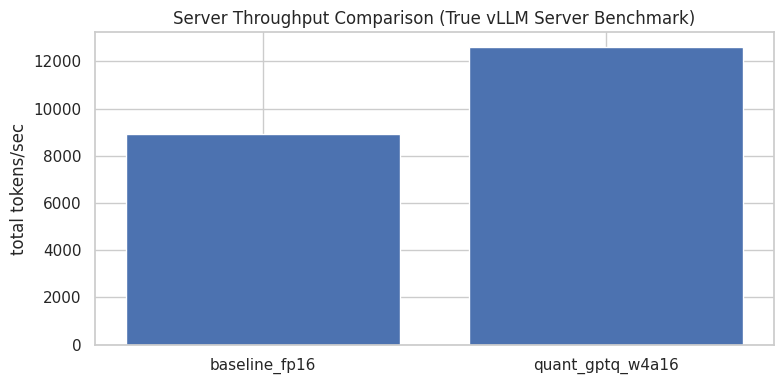

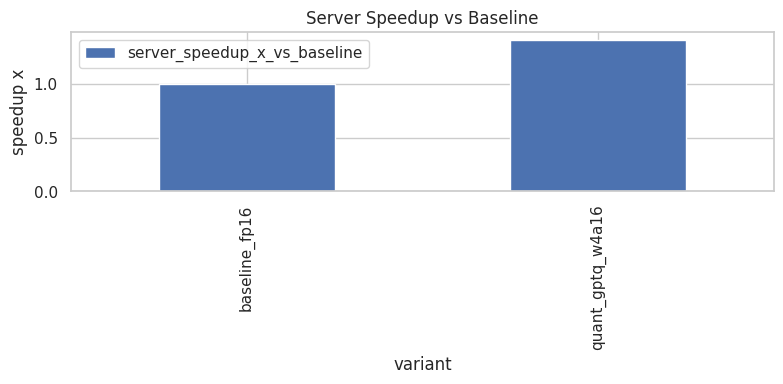

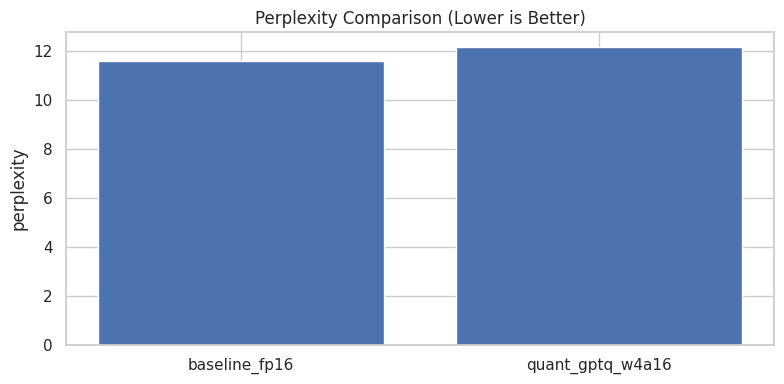

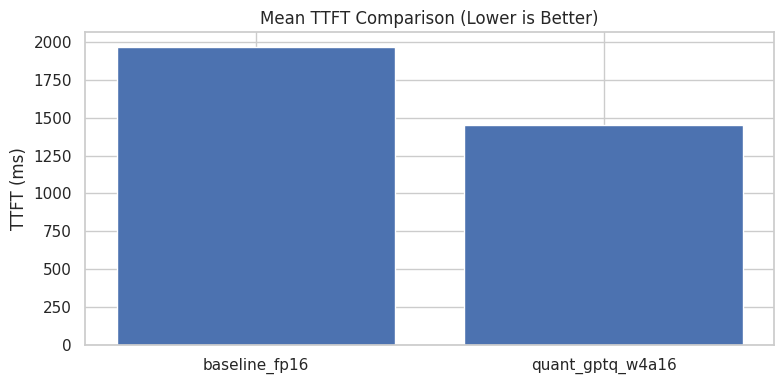

In [19]:
# Throughput comparison
plt.figure(figsize=(8, 4))
plot = final_summary.dropna(subset=['server_total_toks_per_s']).copy()
plt.bar(plot['variant'], plot['server_total_toks_per_s'])
plt.title('Server Throughput Comparison (True vLLM Server Benchmark)')
plt.ylabel('total tokens/sec')
plt.tight_layout()
plt.savefig(DIRS['figures'] / 'server_throughput_comparison.png', dpi=160)
plt.show()

# Speedup comparison
plt.figure(figsize=(8, 4))
spd = final_summary[['variant', 'server_speedup_x_vs_baseline']].set_index('variant')
spd.plot(kind='bar', ax=plt.gca())
plt.title('Server Speedup vs Baseline')
plt.ylabel('speedup x')
plt.tight_layout()
plt.savefig(DIRS['figures'] / 'speedup_comparison.png', dpi=160)
plt.show()

# Perplexity comparison
plt.figure(figsize=(8, 4))
ppl_plot = final_summary[['variant', 'perplexity']].dropna()
plt.bar(ppl_plot['variant'], ppl_plot['perplexity'])
plt.title('Perplexity Comparison (Lower is Better)')
plt.ylabel('perplexity')
plt.tight_layout()
plt.savefig(DIRS['figures'] / 'perplexity_comparison.png', dpi=160)
plt.show()

# TTFT comparison
plt.figure(figsize=(8, 4))
ttft_plot = final_summary[['variant', 'server_mean_ttft_ms']].dropna()
plt.bar(ttft_plot['variant'], ttft_plot['server_mean_ttft_ms'])
plt.title('Mean TTFT Comparison (Lower is Better)')
plt.ylabel('TTFT (ms)')
plt.tight_layout()
plt.savefig(DIRS['figures'] / 'ttft_comparison.png', dpi=160)
plt.show()

### Final interpretation template

- Quantization impact on speed is best judged from **server benchmark** metrics.
- Microbenchmark helps isolate model/runtime effects but excludes API/server scheduling effects.
- Perplexity differences quantify quality tradeoff when available.
- Any unavailable quantized perplexity should be treated as a compatibility limitation, not as evidence of unchanged quality.
- All findings are specific to this software stack and 1x NVIDIA L4 on Vast.ai.

## SECTION 11 — Artifact completeness and export

In [20]:
required_files = [
    ROOT / 'config.json',
    DIRS['summary'] / 'environment.json',
    DIRS['summary'] / 'micro_baseline_summary.csv',
    DIRS['summary'] / 'micro_quant_summary.csv',
    DIRS['summary'] / 'server_tuning_sweep.csv',
    DIRS['summary'] / 'server_summary_server_baseline_fp16.csv',
    DIRS['summary'] / 'server_summary_server_quant_gptq_w4a16.csv',
    DIRS['summary'] / 'perplexity_summary.csv',
    DIRS['summary'] / 'final_summary.csv',
    DIRS['figures'] / 'micro_throughput_comparison.png',
    DIRS['figures'] / 'server_throughput_comparison.png',
    DIRS['figures'] / 'speedup_comparison.png',
    DIRS['figures'] / 'perplexity_comparison.png',
]

missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise AssertionError('Missing required artifacts:\\n' + '\\n'.join(missing))


In [21]:
# Vast.ai-friendly artifact zip command (run in notebook cell)
zip_path = ROOT.parent / f"{ROOT.name}.zip"
cmd = ['zip', '-r', str(zip_path), str(ROOT)]
print('Running:', ' '.join(cmd))
cp = run_cmd(cmd)
if cp.returncode != 0:
    print('zip stderr:', cp.stderr)
    raise RuntimeError('Failed to create artifact zip.')
print('Created:', zip_path)

Running: zip -r artifacts/qwen3_4b_l4_final/20260324_190308_utc.zip artifacts/qwen3_4b_l4_final/20260324_190308_utc
Created: artifacts/qwen3_4b_l4_final/20260324_190308_utc.zip


### Vast.ai shell examples
```bash
# inspect recent logs
ls -lah artifacts/qwen3_1_7b_l4_final/*/logs/

# copy zip out of notebook workspace (example)
ls -lah artifacts/qwen3_1_7b_l4_final/*.zip
```